Running initial baseline calibration (this takes a moment)...
  -> Tx=0.170 µs, Tz=57.2 µs
  -> Probes set to X=0.085 µs, Z=28.6 µs

Starting Continuous Tracking with CMA-ES (drift on g_2)...
Epoch   0 | Mean Reward: -1.066 | Applied g2: +1.077 -0.030j | Ideal: +0.995 -0.100j
Epoch  10 | Mean Reward: -0.717 | Applied g2: +2.227 -0.491j | Ideal: +0.875 -0.027j
Epoch  20 | Mean Reward: -0.710 | Applied g2: +2.846 -0.027j | Ideal: +0.916 +0.074j
Epoch  30 | Mean Reward: -0.675 | Applied g2: +2.967 -0.802j | Ideal: +1.093 +0.089j
Epoch  40 | Mean Reward: -0.683 | Applied g2: +2.935 -0.866j | Ideal: +1.166 -0.036j
Epoch  50 | Mean Reward: -0.653 | Applied g2: +2.982 -0.895j | Ideal: +0.995 -0.100j
Epoch  60 | Mean Reward: -0.624 | Applied g2: +2.980 -0.960j | Ideal: +0.875 -0.027j
Epoch  70 | Mean Reward: -0.628 | Applied g2: +2.996 -0.901j | Ideal: +0.916 +0.074j
Epoch  80 | Mean Reward: -0.671 | Applied g2: +2.933 -0.798j | Ideal: +1.093 +0.089j
Epoch  90 | Mean Reward: -0.673 | Applied g

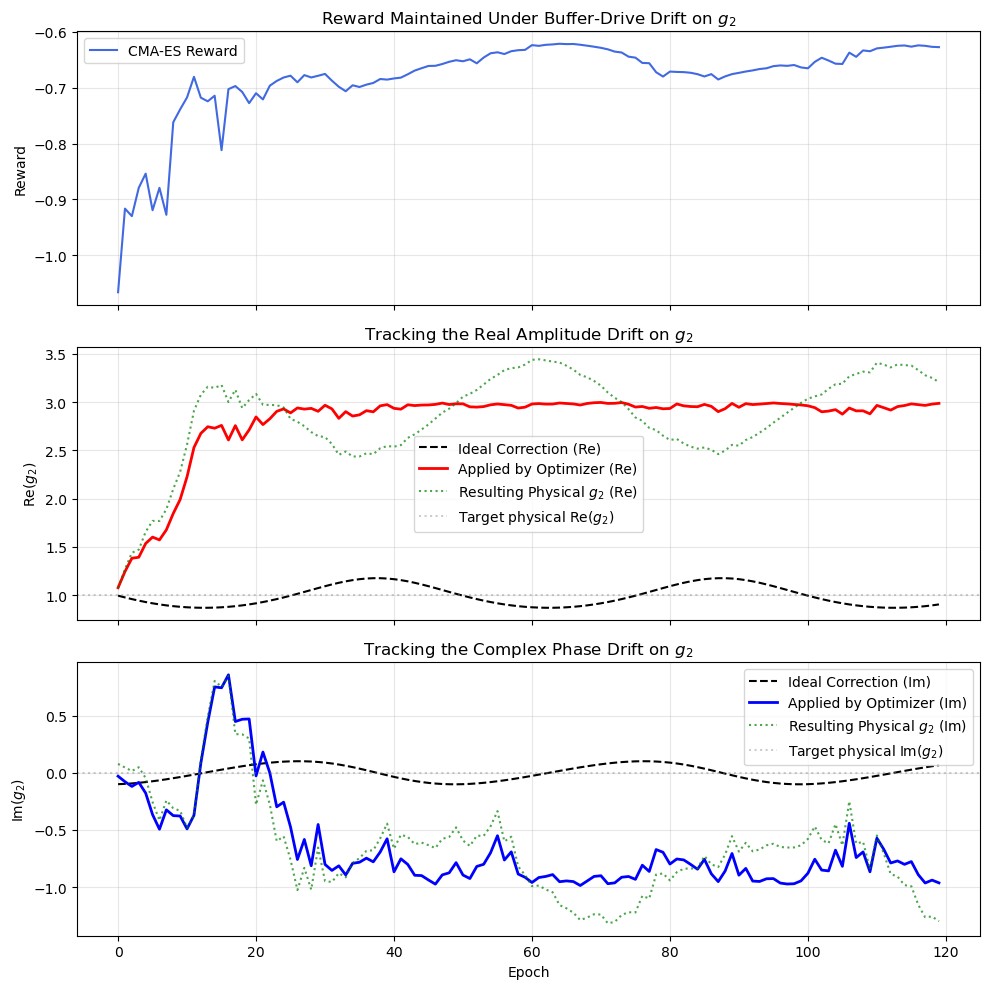

In [3]:
# Uncomment the line below if you need to install the dependencies first
# !pip install "dynamiqs>=0.3.0" cmaes scipy numpy matplotlib

import dynamiqs as dq
import jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from cmaes import CMA
import numpy as np
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 1. System Parameters & Ideal Controls
# ==========================================
na = 15
nb = 5
ka = 1.0
kb = 10.0

# Ideal nominal controls
g_2_nom   = 1.0 + 0j
eps_d_nom = 4.0 + 0j

# ==========================================
# 2. Cat Qubit Simulation (Dynamiqs)
# ==========================================
def make_operators():
    a = dq.tensor(dq.destroy(na), dq.eye(nb))
    b = dq.tensor(dq.eye(na), dq.destroy(nb))
    return a, b

def measure_lifetime(initial_state, tfinal, eps_d, g_2, ntimes=100):
    """Simulates the cat qubit under the given physical parameters."""
    a, b = make_operators()

    eps_2   = 2 * g_2 * eps_d / kb
    kappa_2 = 4 * jnp.abs(g_2)**2 / kb
    cat_arg = 2 / kappa_2 * (eps_2 - ka / 4)

    if float(cat_arg.real) <= 0:
        raise ValueError(f"Unphysical parameters: cat_arg={float(cat_arg.real):.4f}")

    alpha = jnp.sqrt(cat_arg)

    H = (jnp.conj(g_2) * a @ a @ b.dag()
         + g_2 * a.dag() @ a.dag() @ b
         - eps_d * b.dag()
         - jnp.conj(eps_d) * b)

    loss_b = jnp.sqrt(kb) * b
    loss_a = jnp.sqrt(ka) * a

    tsave = jnp.linspace(0, tfinal, ntimes)

    g_state = dq.coherent(na, alpha)
    e_state = dq.coherent(na, -alpha)

    basis = {
        '+z': g_state,
        '-z': e_state,
        '+x': (g_state + e_state) / jnp.sqrt(2)
    }

    sx = (1j * jnp.pi * a.dag() @ a).expm()
    sz = dq.tensor(g_state @ g_state.dag() - e_state @ e_state.dag(), dq.eye(nb))

    psi0 = dq.tensor(basis[initial_state], dq.fock(nb, 0))

    res = dq.mesolve(
        H, [loss_b, loss_a], psi0, tsave,
        options=dq.Options(progress_meter=False),
        exp_ops=[sx, sz]
    )
    return res

# ==========================================
# 3. Dynamic Baseline Calibration
# ==========================================
def exp_model(p, t):
    A, tau, C = p
    return A * np.exp(-t / tau) + C

def robust_exp_fit(t, y):
    t = np.array(t)
    y = np.array(y)
    A0   = float(y.max() - y.min())
    C0   = float(y.min())
    tau0 = float(t.max() - t.min())
    res = least_squares(
        lambda p: exp_model(p, t) - y,
        [A0, tau0, C0],
        bounds=([0, 1e-6, -np.inf], [np.inf, np.inf, np.inf]),
        loss='soft_l1',
        f_scale=0.1
    )
    return res.x[1]

def compute_baseline(g_2, eps_d):
    print("Running initial baseline calibration (this takes a moment)...")

    tfinal_x = 8.0
    res_x = measure_lifetime('+x', tfinal_x, eps_d, g_2, ntimes=100)
    Tx = robust_exp_fit(np.linspace(0, tfinal_x, 100), res_x.expects[0].real)

    tfinal_z = 300.0
    res_z = measure_lifetime('+z', tfinal_z, eps_d, g_2, ntimes=100)
    Tz = robust_exp_fit(np.linspace(0, tfinal_z, 100), res_z.expects[1].real)

    T_probe_x = 0.5 * Tx
    T_probe_z = 0.5 * Tz

    res_xp = measure_lifetime('+x', T_probe_x, eps_d, g_2, ntimes=5)
    res_zp = measure_lifetime('+z', T_probe_z, eps_d, g_2, ntimes=5)
    sx_nom = float(res_xp.expects[0].real[-1])
    sz_nom = float(res_zp.expects[1].real[-1])

    print(f"  -> Tx={Tx:.3f} µs, Tz={Tz:.1f} µs")
    print(f"  -> Probes set to X={T_probe_x:.3f} µs, Z={T_probe_z:.1f} µs\n")

    return T_probe_x, T_probe_z, float(np.log(sz_nom + 1e-9) - np.log(sx_nom + 1e-9))

T_PROBE_X, T_PROBE_Z, LOG_BIAS_TARGET = compute_baseline(g_2_nom, eps_d_nom)

# ==========================================
# 4. Reward & Tracker Loop
# ==========================================
def reward(g2_phys, eps_d_phys, w_lifetime=1.0, w_bias=2.0, eps=1e-9):
    res_x = measure_lifetime('+x', T_PROBE_X, eps_d_phys, g2_phys, ntimes=5)
    sx = float(res_x.expects[0].real[-1])

    res_z = measure_lifetime('+z', T_PROBE_Z, eps_d_phys, g2_phys, ntimes=5)
    sz = float(res_z.expects[1].real[-1])

    log_sx = np.log(max(sx, eps))
    log_sz = np.log(max(sz, eps))

    r_lifetime = log_sx + log_sz
    r_bias = -w_bias * ((log_sz - log_sx) - LOG_BIAS_TARGET) ** 2

    return w_lifetime * r_lifetime + r_bias

def get_buffer_drive_drift(epoch):
    """Simulates a complex amplitude drift on the buffer-drive coupling g_2.
    Per the task: 'introduce a complex amplitude prefactor in the g_2 term
    that drifts with epoch'."""
    period = 50.0
    amplitude_drift = 1.0 + 0.15 * np.sin(2 * np.pi * epoch / period)
    phase_drift     = 0.1 * np.cos(2 * np.pi * epoch / period)
    return amplitude_drift * np.exp(1j * phase_drift)

def run_drifting_cmaes(n_epochs=120, batch_size=8, sigma0=0.2, seed=42):
    BOUNDS = np.array([
        [0.1,  3.0],   # Re(g2)
        [-1.0, 1.0],   # Im(g2)  <-- now the one that needs to absorb phase drift
        [1.0,  8.0],   # Re(eps_d)
        [-3.0, 3.0],   # Im(eps_d)
    ])

    mean0 = np.array([
        float(g_2_nom.real), float(g_2_nom.imag),
        float(eps_d_nom.real), float(eps_d_nom.imag),
    ])

    optimizer = CMA(mean=mean0, sigma=sigma0, bounds=BOUNDS,
                    population_size=batch_size, seed=seed)

    history = {
        'rewards': [],
        'applied_g2': [],
        'physical_g2': [],
        'ideal_applied_g2': [],
    }

    print("Starting Continuous Tracking with CMA-ES (drift on g_2)...")
    for epoch in range(n_epochs):
        current_drift = get_buffer_drive_drift(epoch)

        # What the optimizer SHOULD output to counter the hardware drift on g_2
        ideal_applied = g_2_nom / current_drift
        history['ideal_applied_g2'].append(ideal_applied)

        # Prevent CMA-ES from going completely blind after initial convergence
        if optimizer._sigma < 0.1:
            optimizer._sigma = 0.1

        xs = np.array([optimizer.ask() for _ in range(optimizer.population_size)])
        rewards = []

        for x in xs:
            g2_applied    = complex(x[0], x[1])
            eps_d_applied = complex(x[2], x[3])

            # *** FIX: hardware drift corrupts g_2 (buffer-drive coupling) ***
            g2_phys    = g2_applied * current_drift
            eps_d_phys = eps_d_applied  # eps_d itself is not drifted

            # Physics bounds check
            eps_2   = 2 * g2_phys * eps_d_phys / kb
            kappa_2 = 4 * abs(g2_phys)**2 / kb
            cat_arg = 2 / kappa_2 * (eps_2 - ka / 4)

            if float(np.real(cat_arg)) <= 0:
                rewards.append(-50.0)
            else:
                try:
                    r = reward(g2_phys, eps_d_phys)
                    rewards.append(r)
                except Exception:
                    rewards.append(-50.0)

        # Update optimizer (CMA-ES minimizes, so we negate)
        solutions = [(xs[j], -rewards[j]) for j in range(len(xs))]
        optimizer.tell(solutions)

        epoch_reward = float(np.mean(rewards))
        history['rewards'].append(epoch_reward)

        mean_g2_applied = complex(optimizer.mean[0], optimizer.mean[1])
        history['applied_g2'].append(mean_g2_applied)
        history['physical_g2'].append(mean_g2_applied * current_drift)

        if epoch % 10 == 0:
            print(f"Epoch {epoch:3d} | Mean Reward: {epoch_reward:.3f} | "
                  f"Applied g2: {mean_g2_applied.real:+.3f} {mean_g2_applied.imag:+.3f}j | "
                  f"Ideal: {ideal_applied.real:+.3f} {ideal_applied.imag:+.3f}j")

    return history

history_drift = run_drifting_cmaes(n_epochs=120)

# ==========================================
# 5. Visualization
# ==========================================
applied_g2  = np.array(history_drift['applied_g2'])
ideal_g2    = np.array(history_drift['ideal_applied_g2'])
physical_g2 = np.array(history_drift['physical_g2'])
rewards     = np.array(history_drift['rewards'])
epochs      = np.arange(len(rewards))

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Plot 1: Reward maintained despite drift
axes[0].plot(epochs, rewards, color='royalblue', label='CMA-ES Reward')
axes[0].set_ylabel("Reward")
axes[0].set_title("Reward Maintained Under Buffer-Drive Drift on $g_2$")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: Real part tracking (g_2)
axes[1].plot(epochs, ideal_g2.real, 'k--', label='Ideal Correction (Re)')
axes[1].plot(epochs, applied_g2.real, 'r-', linewidth=2, label='Applied by Optimizer (Re)')
axes[1].plot(epochs, physical_g2.real, 'g:', alpha=0.7, label='Resulting Physical $g_2$ (Re)')
axes[1].axhline(g_2_nom.real, color='gray', alpha=0.4, linestyle=':',
                label='Target physical Re($g_2$)')
axes[1].set_ylabel("Re($g_2$)")
axes[1].set_title("Tracking the Real Amplitude Drift on $g_2$")
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

# Plot 3: Imaginary part tracking (g_2)
axes[2].plot(epochs, ideal_g2.imag, 'k--', label='Ideal Correction (Im)')
axes[2].plot(epochs, applied_g2.imag, 'b-', linewidth=2, label='Applied by Optimizer (Im)')
axes[2].plot(epochs, physical_g2.imag, 'g:', alpha=0.7, label='Resulting Physical $g_2$ (Im)')
axes[2].axhline(g_2_nom.imag, color='gray', alpha=0.4, linestyle=':',
                label='Target physical Im($g_2$)')
axes[2].set_ylabel("Im($g_2$)")
axes[2].set_xlabel("Epoch")
axes[2].set_title("Tracking the Complex Phase Drift on $g_2$")
axes[2].legend(loc='best')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
